<a href="https://colab.research.google.com/github/tonHS/Canadian-Crime-Trends/blob/main/notebooks/Crime_Stats_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:

# Configure Git with your info
!git config --global user.name "tonHS"
!git config --global user.email "171510635+tonHS@users.noreply.github.com"

# Store credentials so you don't have to enter token every time
!git config --global credential.helper store

In [18]:
# Install Dependencies and Packages
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


In [19]:
# Fetch organized crime data
# Create directories

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
outputs_dir = Path('outputs')
outputs_dir.mkdir(exist_ok=True)

print("=" * 80)
print("FETCHING ORGANIZED CRIME DATA FROM STATISTICS CANADA")
print("=" * 80)

# StatCan table ID for organized crime
TABLE_ID = "35100062"

# Construct the download URL (using the direct ZIP download link)
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

try:
    print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
    print(f"URL: {download_url[:80]}...")

    # Download the data
    response = requests.get(download_url, timeout=30)
    response.raise_for_status()

    # Extract ZIP file
    with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
        # Get the CSV file name (should be the table ID)
        csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]

        if not csv_files:
            raise ValueError("No CSV file found in downloaded ZIP")

        csv_filename = csv_files[0]
        print(f"✓ Downloaded and extracted: {csv_filename}")

        # Read the CSV
        with zip_file.open(csv_filename) as csv_file:
            df = pd.read_csv(csv_file)

    print(f"✓ Data loaded successfully: {len(df):,} rows, {len(df.columns)} columns")

    # Save raw data
    raw_data_path = data_dir / 'organized_crime_raw.csv'
    df.to_csv(raw_data_path, index=False)
    print(f"✓ Raw data saved to: {raw_data_path}")

    # Display basic info
    print(f"\n📊 Dataset Overview:")
    print(f"   • Time period: {df['REF_DATE'].min()} to {df['REF_DATE'].max()}")
    print(f"   • Columns: {', '.join(df.columns.tolist())}")

except requests.exceptions.RequestException as e:
    print(f"❌ Error downloading data: {e}")
    raise
except Exception as e:
    print(f"❌ Error processing data: {e}")
    raise

print("\n" + "=" * 80)
print("✓ DATA FETCH COMPLETE")
print("=" * 80)

FETCHING ORGANIZED CRIME DATA FROM STATISTICS CANADA

📥 Downloading data from Statistics Canada (Table 35100062)...
URL: https://www150.statcan.gc.ca/n1/tbl/csv/35100062-eng.zip...
✓ Downloaded and extracted: 35100062.csv
✓ Data loaded successfully: 702 rows, 15 columns
✓ Raw data saved to: data/organized_crime_raw.csv

📊 Dataset Overview:
   • Time period: 2016 to 2024
   • Columns: REF_DATE, GEO, DGUID, Most serious violation, UOM, UOM_ID, SCALAR_FACTOR, SCALAR_ID, VECTOR, COORDINATE, VALUE, STATUS, SYMBOL, TERMINATED, DECIMALS

✓ DATA FETCH COMPLETE


In [20]:
# Organized Crime - Process and Clean Data
print("=" * 80)
print("PROCESSING ORGANIZED CRIME DATA")
print("=" * 80)

# Display the structure
print(f"\n📋 Data Structure:")
print(df.head())
print(f"\n📊 Column Types:")
print(df.dtypes)

# Clean and prepare the data
# Filter for actual crime violations (not totals in the violation name)
df_clean = df.copy()

# Convert REF_DATE to integer year
df_clean['Year'] = df_clean['REF_DATE'].astype(int)

# Filter for 2016-2024 only
df_clean = df_clean[df_clean['Year'].between(2016, 2024)]

# Get the value column (usually 'VALUE')
value_col = 'VALUE'
if value_col not in df_clean.columns:
    # Try to find the value column
    possible_cols = [col for col in df_clean.columns if 'value' in col.lower()]
    if possible_cols:
        value_col = possible_cols[0]
    else:
        raise ValueError("Could not find value column in data")

print(f"\n✓ Using '{value_col}' as the value column")

# Remove any rows with missing values
df_clean = df_clean[df_clean[value_col].notna()]

# Get violation column name
violation_col = 'Violations'
if violation_col not in df_clean.columns:
    possible_cols = [col for col in df_clean.columns if 'violation' in col.lower()]
    if possible_cols:
        violation_col = possible_cols[0]
    else:
        raise ValueError("Could not find violation column in data")

print(f"✓ Using '{violation_col}' as the violation column")

# Display unique violations
print(f"\n🔍 Unique violations found: {df_clean[violation_col].nunique()}")
print("\nSample violations:")
for i, violation in enumerate(df_clean[violation_col].unique()[:10], 1):
    print(f"   {i}. {violation}")

# Filter out "Total" rows to get specific violations
df_violations = df_clean[~df_clean[violation_col].str.contains('Total', case=False, na=False)]

print(f"\n✓ Filtered to {len(df_violations):,} rows of specific violations")
print(f"✓ Years covered: {df_violations['Year'].min()} to {df_violations['Year'].max()}")
print(f"✓ Number of specific violation types: {df_violations[violation_col].nunique()}")

print("\n" + "=" * 80)
print("✓ DATA PROCESSING COMPLETE")
print("=" * 80)

PROCESSING ORGANIZED CRIME DATA

📋 Data Structure:
   REF_DATE                               GEO           DGUID  \
0      2016  Canada, selected police services  2021A000011124   
1      2016  Canada, selected police services  2021A000011124   
2      2016  Canada, selected police services  2021A000011124   
3      2016  Canada, selected police services  2021A000011124   
4      2016  Canada, selected police services  2021A000011124   

                              Most serious violation     UOM  UOM_ID  \
0                              Total, all violations  Number     223   
1                                          Homicide   Number     223   
2       Attempted murder / Conspire to commit murder  Number     223   
3                                            Assault  Number     223   
4  Sexual violations (not including against child...  Number     223   

  SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  VALUE  STATUS  SYMBOL  \
0         units          0  v1066366742        

In [21]:
# Create Organized Crime Table - Top 20 Crimes in 2024 with Growth Metrics
print("=" * 80)
print("CREATING TOP 20 CRIMES TABLE")
print("=" * 80)

# Get 2024 data
df_2024 = df_violations[df_violations['Year'] == 2024].copy()

# Get 2019 data
df_2019 = df_violations[df_violations['Year'] == 2019].copy()

# Get 2016 data
df_2016 = df_violations[df_violations['Year'] == 2016].copy()

# Calculate totals for each year by violation type
violations_2024 = df_2024.groupby(violation_col)[value_col].sum()
violations_2019 = df_2019.groupby(violation_col)[value_col].sum()
violations_2016 = df_2016.groupby(violation_col)[value_col].sum()

# Get top 20 crimes by 2024 violations
top_20_violations = violations_2024.nlargest(20)

# Create the summary table
summary_data = []

for violation in top_20_violations.index:
    count_2024 = violations_2024.get(violation, 0)
    count_2019 = violations_2019.get(violation, 0)
    count_2016 = violations_2016.get(violation, 0)

    # Calculate growth
    if count_2019 > 0:
        growth_2019_2024 = ((count_2024 - count_2019) / count_2019) * 100
    else:
        growth_2019_2024 = float('inf') if count_2024 > 0 else 0

    if count_2016 > 0:
        growth_2016_2024 = ((count_2024 - count_2016) / count_2016) * 100
    else:
        growth_2016_2024 = float('inf') if count_2024 > 0 else 0

    summary_data.append({
        'Rank': len(summary_data) + 1,
        'Violation Type': violation,
        '2024 Violations': int(count_2024),
        'Growth 2019-2024 (%)': growth_2019_2024,
        'Growth 2016-2024 (%)': growth_2016_2024
    })

# Create DataFrame
df_summary = pd.DataFrame(summary_data)

# Format the table for display
df_display = df_summary.copy()
df_display['2024 Violations'] = df_display['2024 Violations'].apply(lambda x: f'{x:,}')
df_display['Growth 2019-2024 (%)'] = df_display['Growth 2019-2024 (%)'].apply(
    lambda x: 'N/A' if x == float('inf') else f'{x:+.1f}%'
)
df_display['Growth 2016-2024 (%)'] = df_display['Growth 2016-2024 (%)'].apply(
    lambda x: 'N/A' if x == float('inf') else f'{x:+.1f}%'
)

print(f"\n📊 TOP 20 ORGANIZED CRIMES IN CANADA (2024)")
print("=" * 80)
print(df_display.to_string(index=False))
print("=" * 80)

# Save to CSV
csv_path = outputs_dir / 'top_20_crimes_2024_with_growth.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\n✓ Table saved to: {csv_path}")

# Create a nicely formatted display table
from IPython.display import display, HTML

# Style the dataframe for better display
styled_df = df_display.style.set_properties(**{
    'text-align': 'left',
    'font-size': '12px',
    'border-color': 'black'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#2E86AB'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '10px')
    ]},
    {'selector': 'td', 'props': [
        ('padding', '8px'),
        ('border', '1px solid #ddd')
    ]},
    {'selector': 'tr:nth-of-type(even)', 'props': [
        ('background-color', '#f9f9f9')
    ]},
    {'selector': 'tr:hover', 'props': [
        ('background-color', '#f5f5f5')
    ]}
])

print("\n📋 FORMATTED TABLE:")
display(styled_df)

# Print summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
total_2024 = df_summary['2024 Violations'].sum()
avg_growth_2019 = df_summary[df_summary['Growth 2019-2024 (%)'] != float('inf')]['Growth 2019-2024 (%)'].mean()
avg_growth_2016 = df_summary[df_summary['Growth 2016-2024 (%)'] != float('inf')]['Growth 2016-2024 (%)'].mean()

print(f"Total violations in top 20 (2024): {total_2024:,}")
print(f"Average growth (2019-2024): {avg_growth_2019:+.1f}%")
print(f"Average growth (2016-2024): {avg_growth_2016:+.1f}%")

print("\n" + "=" * 80)
print("✓ TABLE GENERATION COMPLETE")
print("=" * 80)

CREATING TOP 20 CRIMES TABLE

📊 TOP 20 ORGANIZED CRIMES IN CANADA (2024)
 Rank                                           Violation Type 2024 Violations Growth 2019-2024 (%) Growth 2016-2024 (%)
    1                                                    Fraud           6,282               +75.5%              +327.9%
    2                                      Motor Vehicle Theft           2,036              +770.1%              +874.2%
    3  Drug (other than cannabis) - trafficking and production           1,094                +4.8%              +127.4%
    4                                          Break and enter             712               +95.6%              +431.3%
    5                                                  Assault             511               +34.8%               +83.8%
    6                                                 Mischief             428               +98.1%              +169.2%
    7                                           Identity Theft             298  

,Rank,Violation Type,2024 Violations,Growth 2019-2024 (%),Growth 2016-2024 (%)
0,1,Fraud,"6,282",+75.5%,+327.9%
1,2,Motor Vehicle Theft,"2,036",+770.1%,+874.2%
2,3,Drug (other than cannabis) - trafficking and production,"1,094",+4.8%,+127.4%
3,4,Break and enter,712,+95.6%,+431.3%
4,5,Assault,511,+34.8%,+83.8%
5,6,Mischief,428,+98.1%,+169.2%
6,7,Identity Theft,298,+302.7%,+2880.0%
7,8,Robbery,286,+43.0%,+155.4%
8,9,"Shoplifting $5,000 or under",220,+91.3%,+254.8%
9,10,Extortion,209,+422.5%,+553.1%



SUMMARY STATISTICS
Total violations in top 20 (2024): 13,508
Average growth (2019-2024): +138.1%
Average growth (2016-2024): +372.8%

✓ TABLE GENERATION COMPLETE


CREATING LINE GRAPH VISUALIZATION

📊 Yearly Totals:
   Year  Total_Violations
0  2016              4810
1  2017              6184
2  2018              6436
3  2019              8513
4  2020             10682
5  2021             10286
6  2022             11155
7  2023             13143
8  2024             14768

🔝 Top 3 Most Common Organized Crime Violations (2016-2024):
   1. Fraud: 35,145 total violations
   2. Drug (other than cannabis) - trafficking and production: 8,516 total violations
   3. Motor Vehicle Theft: 7,702 total violations

✓ Graph saved to: outputs/organized_crime_trends_2016_2024.png


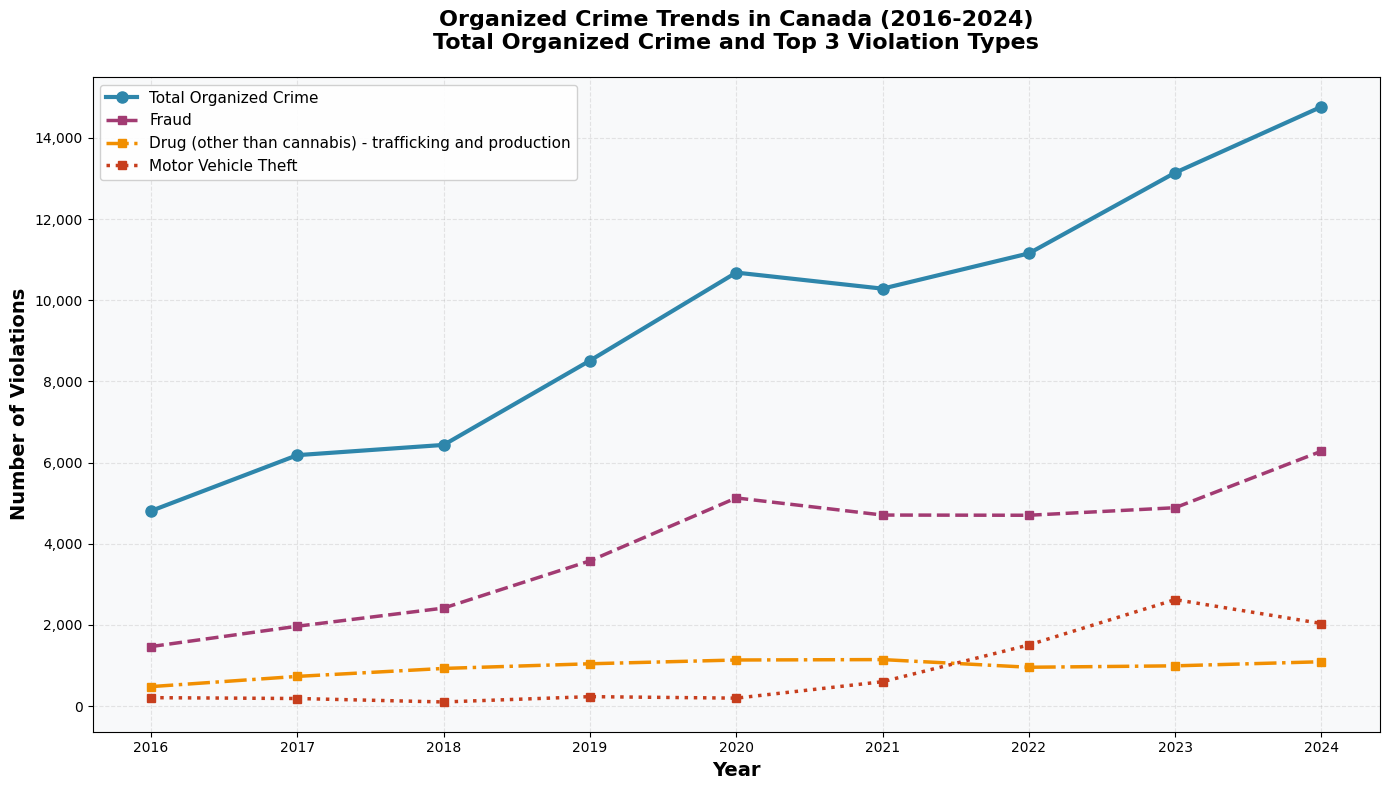


✓ LINE GRAPH COMPLETE


In [22]:
# Create Organized Crime Line Graph - Organized Crime Trends (2016-2024)
print("=" * 80)
print("CREATING LINE GRAPH VISUALIZATION")
print("=" * 80)

# Calculate total organized crime per year
yearly_totals = df_violations.groupby('Year')[value_col].sum().reset_index()
yearly_totals.columns = ['Year', 'Total_Violations']

print(f"\n📊 Yearly Totals:")
print(yearly_totals)

# Find the top 3 most common organized crime violations (by total across all years)
top_violations = df_violations.groupby(violation_col)[value_col].sum().nlargest(3)
print(f"\n🔝 Top 3 Most Common Organized Crime Violations (2016-2024):")
for i, (violation, total) in enumerate(top_violations.items(), 1):
    print(f"   {i}. {violation}: {total:,} total violations")

# Prepare data for the top 3 violations over time
top_3_names = top_violations.index.tolist()
df_top3 = df_violations[df_violations[violation_col].isin(top_3_names)]

# Pivot data for easier plotting
df_pivot = df_top3.pivot_table(
    index='Year',
    columns=violation_col,
    values=value_col,
    aggfunc='sum'
).fillna(0)

# Create the line graph
fig, ax = plt.subplots(figsize=(14, 8))

# Plot total organized crime
ax.plot(yearly_totals['Year'], yearly_totals['Total_Violations'],
        marker='o', linewidth=3, markersize=8,
        label='Total Organized Crime', color='#2E86AB', linestyle='-')

# Define colors for top 3 violations
colors = ['#A23B72', '#F18F01', '#C73E1D']
linestyles = ['--', '-.', ':']

# Plot top 3 violations
for i, violation in enumerate(top_3_names):
    if violation in df_pivot.columns:
        ax.plot(df_pivot.index, df_pivot[violation],
                marker='s', linewidth=2.5, markersize=6,
                label=violation, color=colors[i], linestyle=linestyles[i])

# Formatting
ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Violations', fontsize=14, fontweight='bold')
ax.set_title('Organized Crime Trends in Canada (2016-2024)\nTotal Organized Crime and Top 3 Violation Types',
             fontsize=16, fontweight='bold', pad=20)

# Format axes
ax.set_xticks(range(2016, 2025))
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best', framealpha=0.9)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add subtle background
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')

plt.tight_layout()

# Save the figure
output_path = outputs_dir / 'organized_crime_trends_2016_2024.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Graph saved to: {output_path}")

plt.show()

print("\n" + "=" * 80)
print("✓ LINE GRAPH COMPLETE")
print("=" * 80)

In [23]:
# CSI: Fetch Data

# Define the table PID
pid = '35100026'

# Fetch the download URL from the API
api_url = f"https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/{pid}/en"
response = requests.get(api_url)

if not response.ok:
    raise ValueError(f"API request failed: {response.status_code} - {response.text}")

zip_url = response.json()['object']

# Download the ZIP file
zip_response = requests.get(zip_url)

if not zip_response.ok:
    raise ValueError(f"Data download failed: {zip_response.status_code} - {zip_response.text}")

# Extract and load the CSV
with zipfile.ZipFile(BytesIO(zip_response.content)) as z:
    csv_filename = f"{pid.replace('-', '')}.csv"
    if csv_filename not in z.namelist():
        raise ValueError("CSV file not found in ZIP")
    df = pd.read_csv(z.open(csv_filename), low_memory=False)

print("Data loaded successfully.")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Data loaded successfully.
Shape: (22908, 15)
Columns: ['REF_DATE', 'GEO', 'DGUID', 'Statistics', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


In [24]:
# ============================================================
# CSI: Filter and Process Data
# ============================================================

# Filter for Canada and relevant indices
df_filtered = df[(df['GEO'] == 'Canada') &
                 (df['Statistics'].isin(['Crime severity index',
                                                   'Violent crime severity index',
                                                   'Non-violent crime severity index']))]

# Pivot the data for plotting
pivot_df = df_filtered.pivot(index='REF_DATE',
                              columns='Statistics',
                              values='VALUE').reset_index()

# Ensure data covers 1998-2024
available_years = pivot_df['REF_DATE'].unique()
print(f"Available years: {sorted(available_years)}")

if not all(year in available_years for year in range(1998, 2025)):
    print("Warning: Data does not cover the full range from 1998 to 2024")
    print(f"Missing years: {set(range(1998, 2025)) - set(available_years)}")

print(f"\nData preview:")
print(pivot_df.head())
print(f"\nData shape: {pivot_df.shape}")

Available years: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Data preview:
Statistics  REF_DATE  Crime severity index  Non-violent crime severity index  \
0               1998                118.84                            126.93   
1               1999                111.24                            115.80   
2               2000                106.73                            110.17   
3               2001                105.30                            108.41   
4               2002                104.14                            107.19   

Statistics  Violent crime severity index  
0          

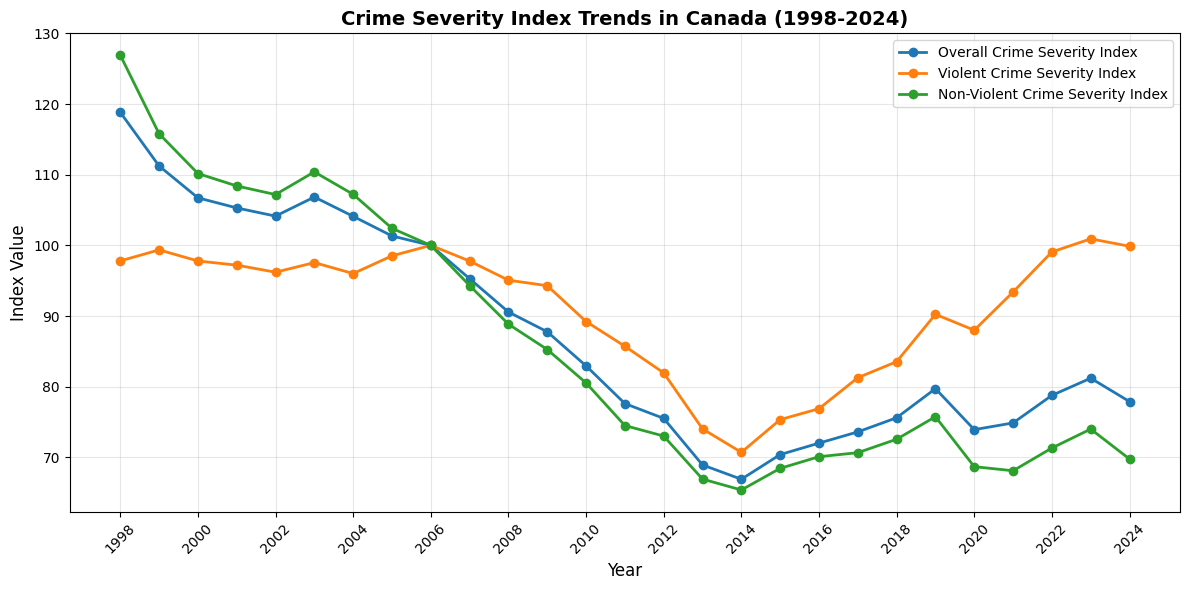

In [25]:

# ============================================================
# CSI: Create Visualization
# ============================================================

# Plot the line graph
plt.figure(figsize=(12, 6))
plt.plot(pivot_df['REF_DATE'], pivot_df['Crime severity index'],
         label='Overall Crime Severity Index', marker='o', linewidth=2)
plt.plot(pivot_df['REF_DATE'], pivot_df['Violent crime severity index'],
         label='Violent Crime Severity Index', marker='o', linewidth=2)
plt.plot(pivot_df['REF_DATE'], pivot_df['Non-violent crime severity index'],
         label='Non-Violent Crime Severity Index', marker='o', linewidth=2)

plt.title('Crime Severity Index Trends in Canada (1998-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks(range(1998, 2025, 2), rotation=45)
plt.tight_layout()
plt.show()



In [26]:

# ============================================================
# CSI: Calculate Growth Rates
# ============================================================

# Extract values for 2019 and 2024
df_2019 = pivot_df[pivot_df['REF_DATE'] == 2019].set_index('REF_DATE')
df_2024 = pivot_df[pivot_df['REF_DATE'] == 2024].set_index('REF_DATE')

if df_2019.empty:
    print("Warning: No data available for 2019")
if df_2024.empty:
    print("Warning: No data available for 2024")

if not df_2019.empty and not df_2024.empty:
    # Calculate growth rates using iloc[0] to access the single row of values
    growth_rates = ((df_2024.iloc[0] - df_2019.iloc[0]) / df_2019.iloc[0] * 100).round(2)

    # Convert the resulting Series to a DataFrame with the desired column name
    growth_rates = growth_rates.to_frame(name='Growth Rate 2019-2024 (%)')

    # Display as a table
    print("\nGrowth Rates from 2019 to 2024:")
    print(growth_rates)
    print("\n" + "="*50)

    # Also display the actual values for context
    print("\n2019 Values:")
    print(df_2019.T)
    print("\n2024 Values:")
    print(df_2024.T)
else:
    print("Cannot calculate growth rates - missing data for 2019 or 2024")


Growth Rates from 2019 to 2024:
                                  Growth Rate 2019-2024 (%)
Statistics                                                 
Crime severity index                                  -2.30
Non-violent crime severity index                      -7.91
Violent crime severity index                          10.67


2019 Values:
REF_DATE                           2019
Statistics                             
Crime severity index              79.72
Non-violent crime severity index  75.75
Violent crime severity index      90.24

2024 Values:
REF_DATE                           2024
Statistics                             
Crime severity index              77.89
Non-violent crime severity index  69.76
Violent crime severity index      99.87
